In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from scipy import stats
import pathlib

In [ ]:
## Read in domains with Mets
# Make list of file names
directory = pathlib.Path("../outputs/In_out")
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

# make reference lists of met numbers and corresponding list of domain names (should really be a dict but it was too late to change it)
met_nos = [1,1,2,3,7,17,2,23,13,4]
domains_order = ['AKPT_Liver_Mets_4d_2_Region_1', 
                'AKPT_Liver_Mets_4d_3_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_2', 
                'AKPT_Liver_Mets_4d_5_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_2', 
                'AKPT_Liver_Mets_28d_1_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_1',
                'AKPT_Liver_Mets_28d_3_Region_1',
                'AKPT_Liver_Mets_28d_1_Region_2']

# read in domains from file names
list_of_domains = []
for i in range(len(list_of_files)):
    list_of_domains.append(ms.io.load_domain(list_of_files[i], print_summary=False))

Plots distribution of cell types relative to the Met boundaries (all distances inside distinct met regions are used together for each sample). Inside the met has negative distances, outside the met has positive distances

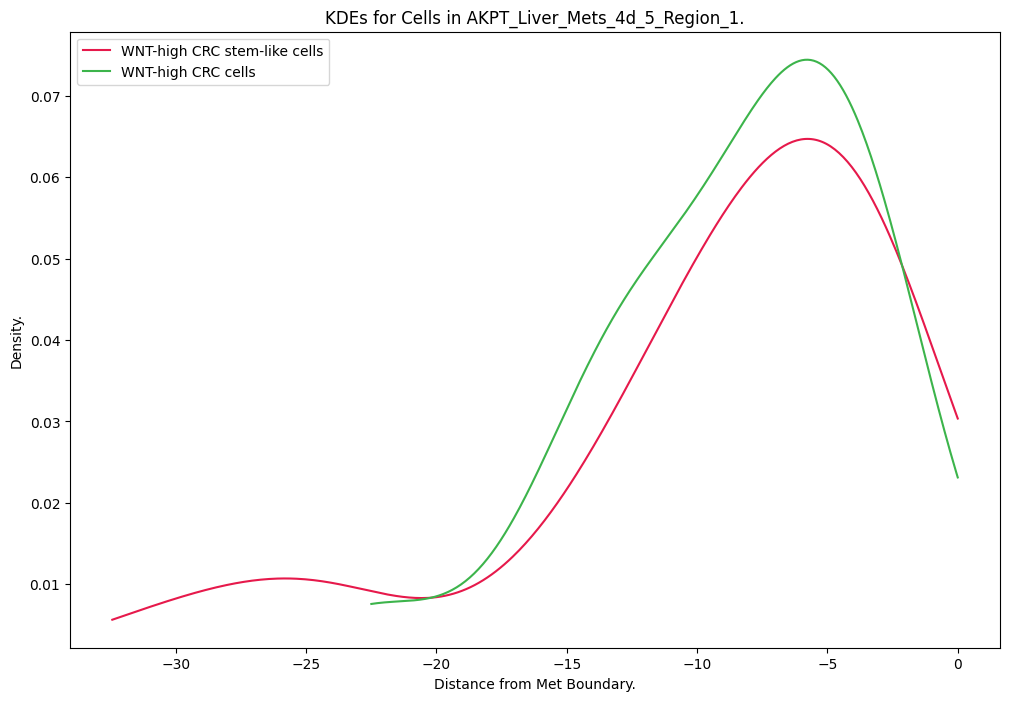

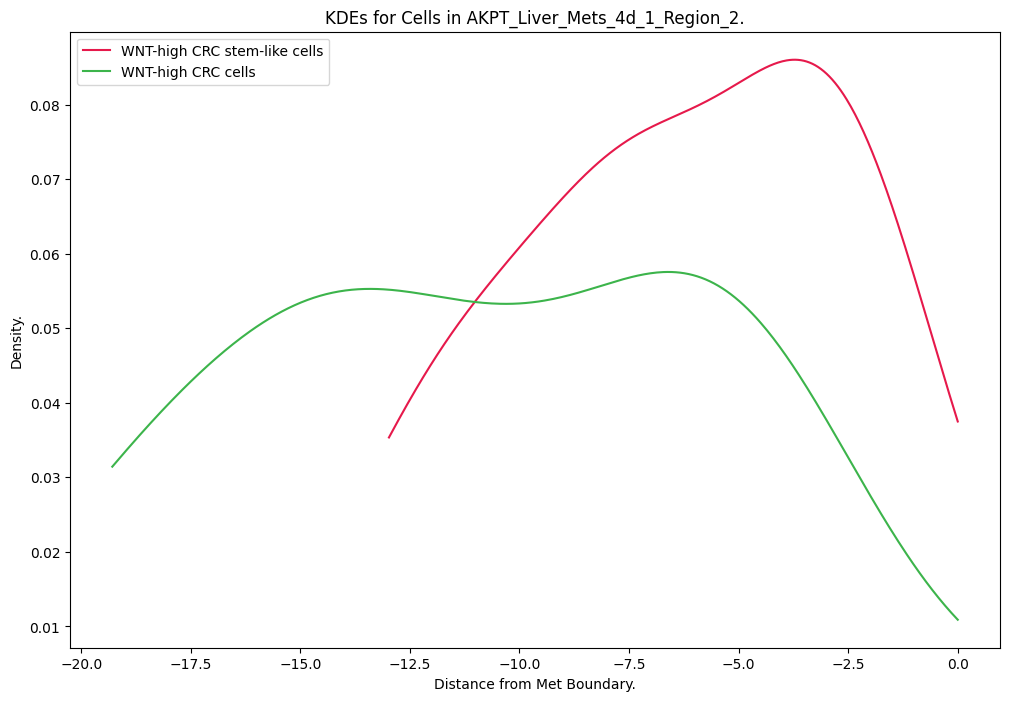

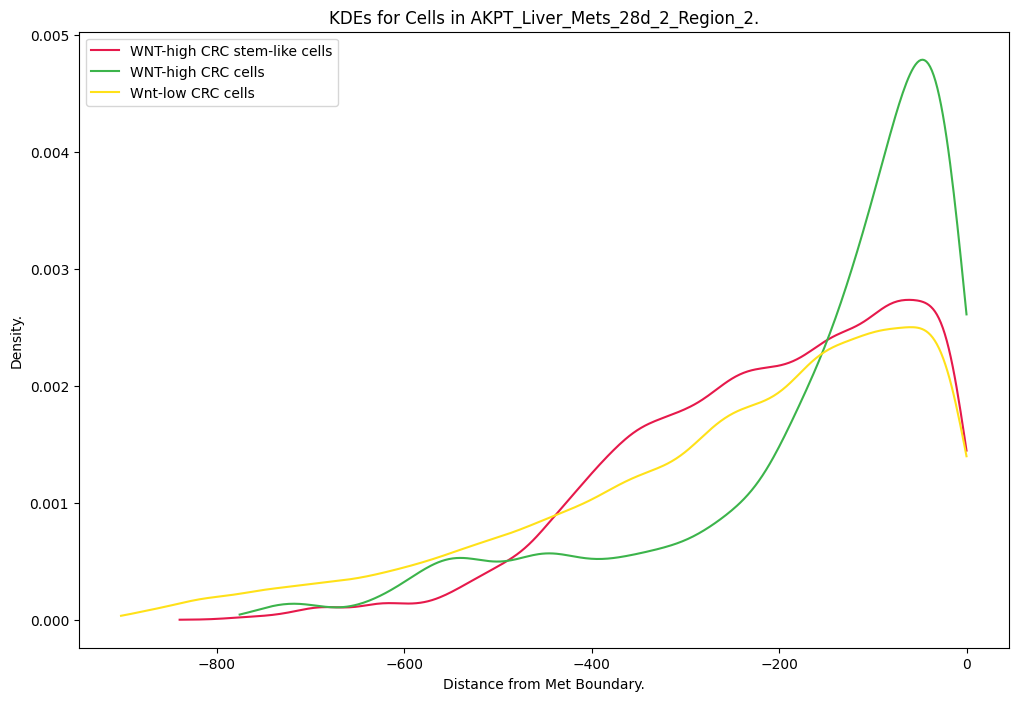

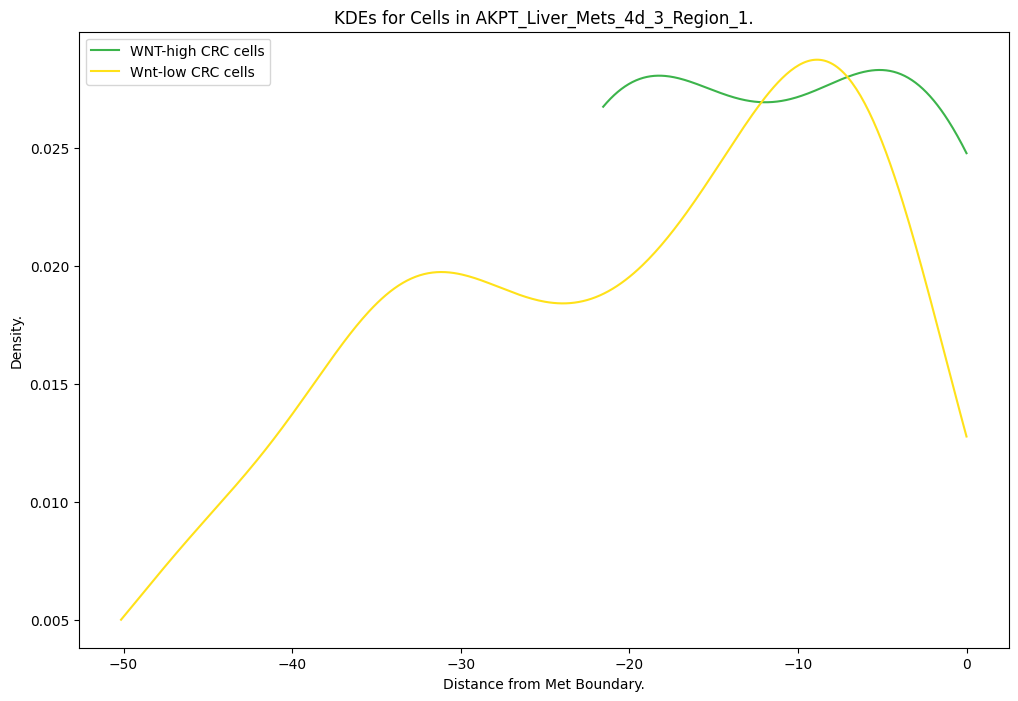

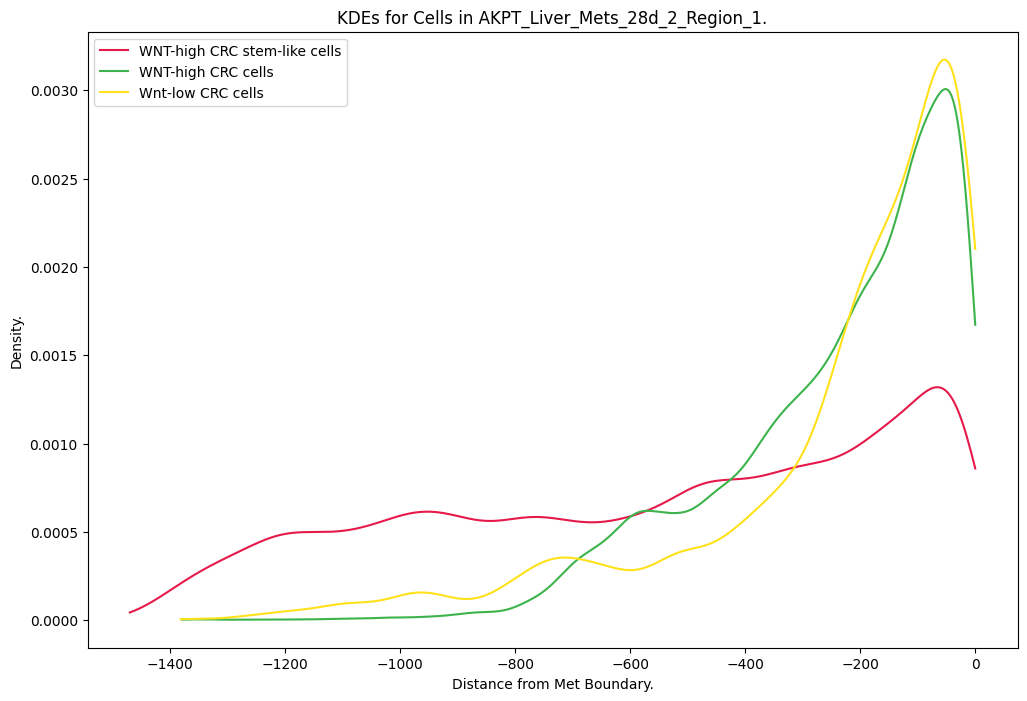

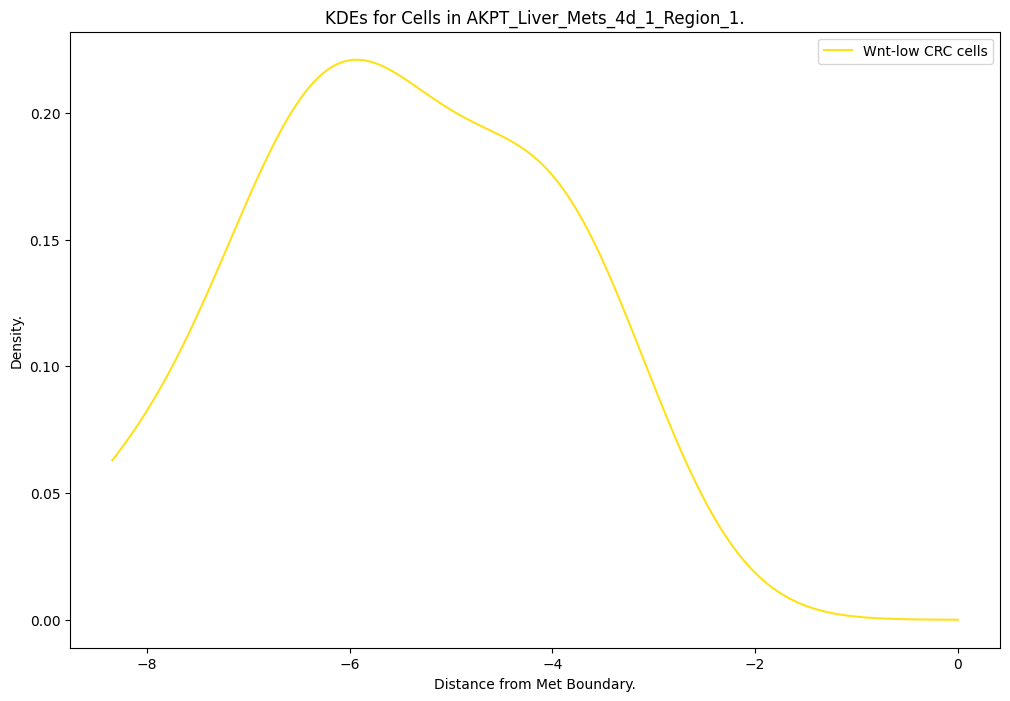

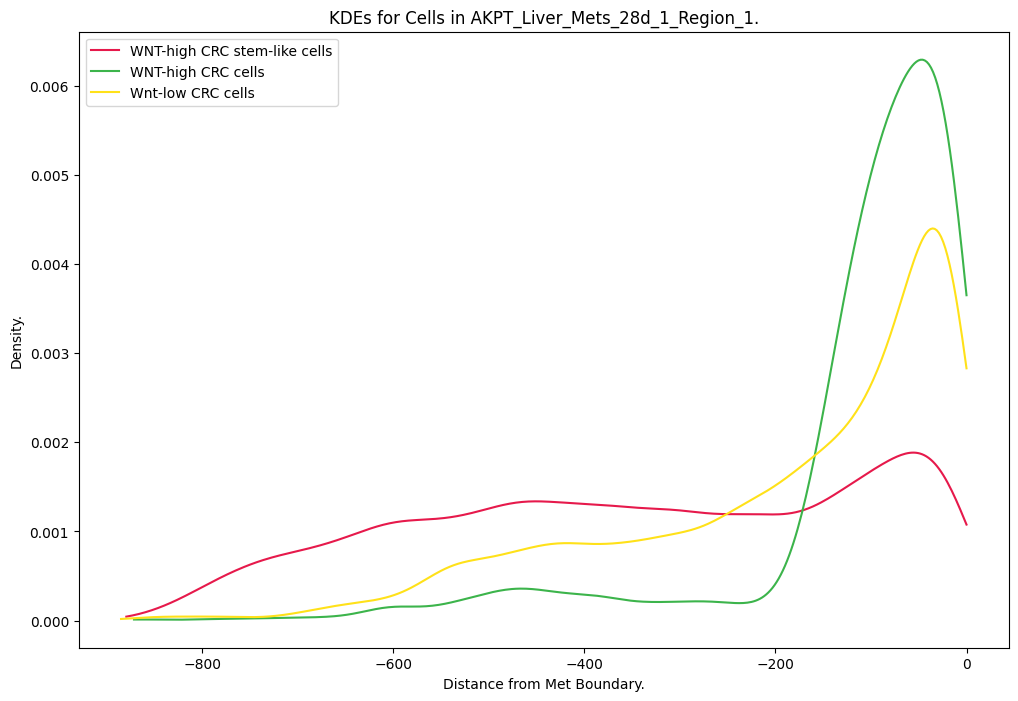

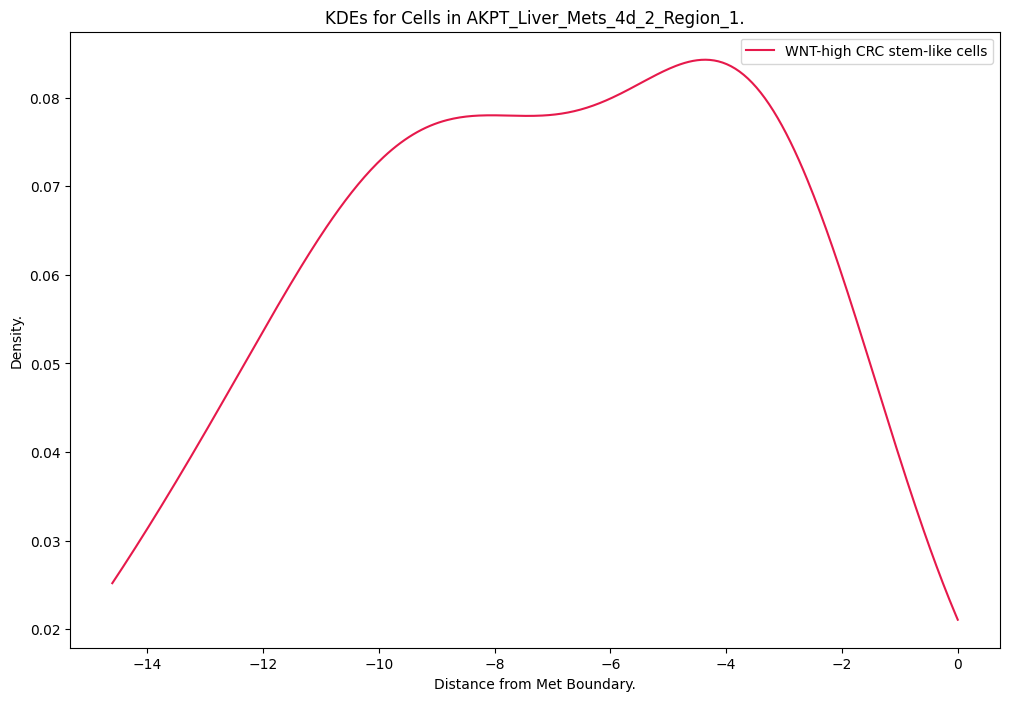

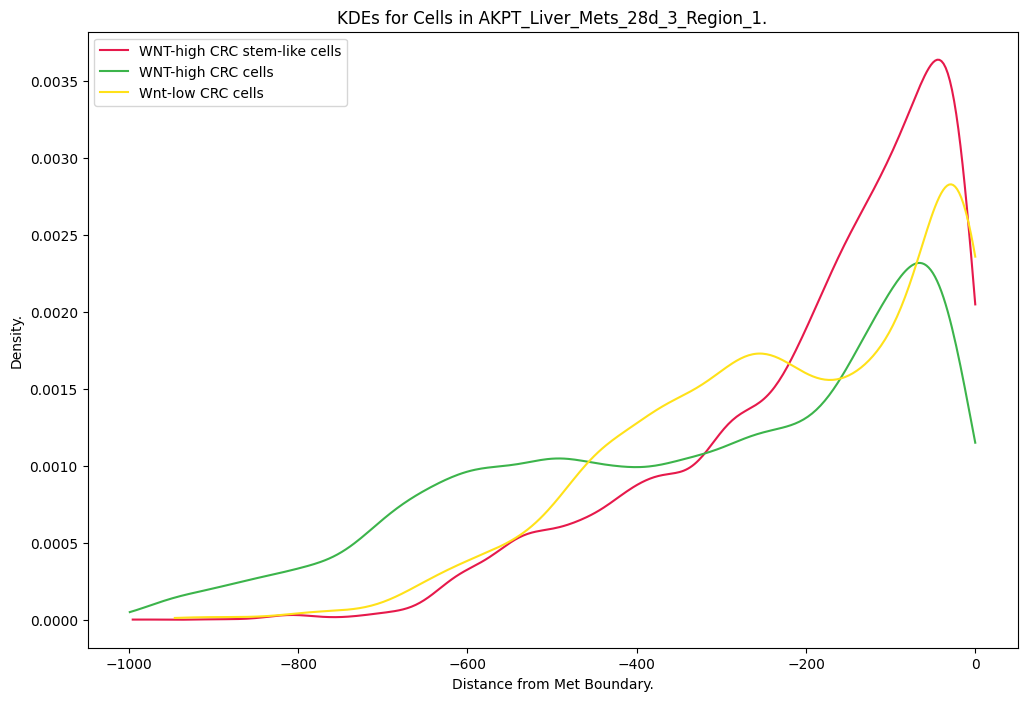

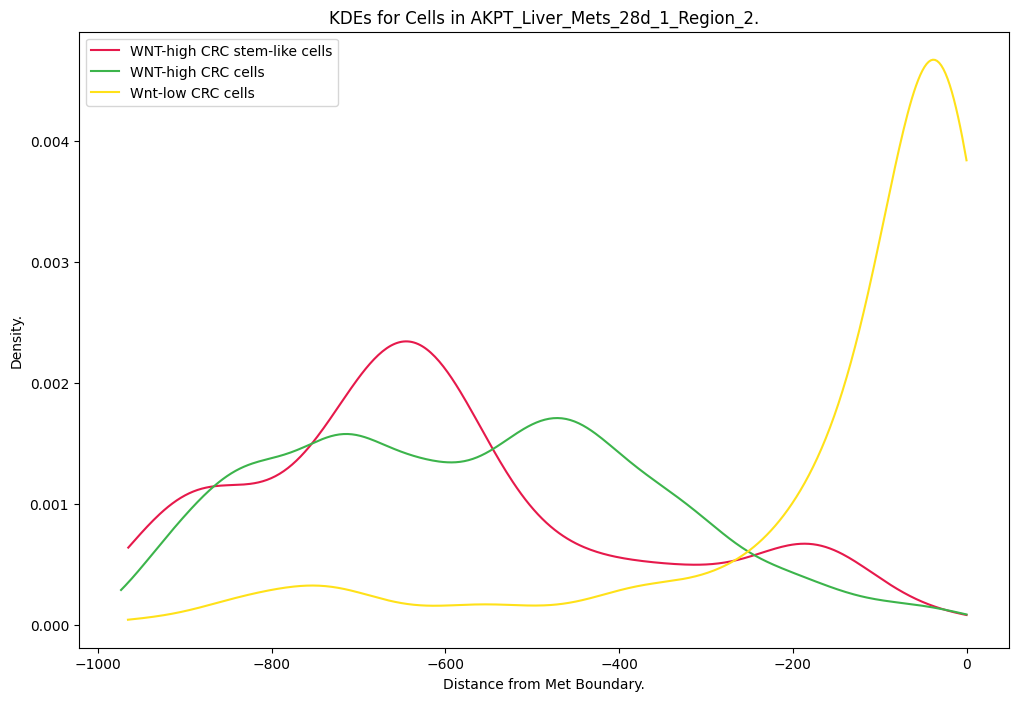

In [ ]:
# specify cell type/types of interest choose as many as you'd like - also set the label_name to the relevant option from
#  'Detailed celltype (liver)', 'Broad celltype (liver)', 'Global celltype'
celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
label_name = 'Detailed celltype (liver)'

colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    # figures
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    axes.set_title('KDEs for Cells in ' +str(domain.name)+'.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Density.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)

    # met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

    # out distances
    shape_cell_distances_out = all_out_distances[domains_order.index(str(domain.name))]
    distances_out = [sublist[1] for sublist in shape_cell_distances_out]
    list_of_max_out_dists.append(np.max(distances_out))


all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    for celltype_no in range(len(celltypes)):
        celltype = celltypes[celltype_no]
        all_relevant_distances = []
        overall_x_min = 0
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        all_normalised_distances = []
        all_kdes = []
        all_regions_distances = []
        for region_no in range(met_no):
            query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            shape_cell_distances = all_met_distances[dom][region_no]
            distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
            all_regions_distances.append(distances)
            if len(distances) > 1:
                x_max = np.max(distances)
                x_min = -x_max
                if x_min < overall_x_min:
                    overall_x_min = x_min
                kde = stats.gaussian_kde(distances)
                x_eval = np.linspace(0, x_max, num=200)
                array_temp = np.array(x_eval)*-1
                x = list(array_temp)
                distances_new = [-x for x in distances]
                all_relevant_distances.extend(distances_new)

        query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
        specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        shape_cell_distances = all_out_distances[dom]
        distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
        x_max = 0
        if len(distances) > 1:
            all_relevant_distances.extend(distances)
            x_max = np.max(distances)
            kde = stats.gaussian_kde(distances)
            x_eval = np.linspace(0, x_max, num=200)
        if len(all_relevant_distances) > 1:
            kde = stats.gaussian_kde(all_relevant_distances)
            x_eval = np.linspace(overall_x_min, x_max, num=400)
            list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[celltype_no], label=celltype)


for dom in range(len(list_of_domains)):
    leg = list_of_axes[dom].legend()
    list_of_figs[dom].savefig('../outputs/WNT_plots/WNT_distribution_for_'+str(list_of_domains[dom].name)+'.png')